# Trend on MAR_EC_Earth3

1. Environment

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import calendar as cld
import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator
from matplotlib.colors import BoundaryNorm
from scipy import stats
import os
import gdown
from tqdm import tqdm

from scipy.stats import linregress

1.1 Functions

In [2]:
# function for seasonal mean (from Ian)
def season_mean(ds, calendar="standard"):
    #make a DataArray with the season of each day
    seas_array = ds.time.dt.season
    
    # count days in winter season (varies with leap years)
    nb_DJF = seas_array.str.count('DJF').sum()
    
    wgt_DJF = 1/nb_DJF.values.item()
    wgt_MAM = 1/(31+30+31)
    wgt_JJA = 1/(30+31+31)
    wgt_SON = 1/(30+31+30)

    weight = seas_array.str.replace('DJF',str(wgt_DJF)).str.replace('MAM',str(wgt_MAM)).str.replace('JJA',str(wgt_JJA)).str.replace('SON',str(wgt_SON))
    weight = weight.astype('float')
    
    # Test that the sum of the weights for each season is 1.0
    np.testing.assert_allclose(weight.groupby("time.season").sum().values, np.ones(4))

    # Calculate the weighted average
    return (ds * weight).groupby("time.season").sum(dim="time")

In [3]:
# define a function to compute seasonal mean
# Taking into account the differet number of days per months
def season_mean(dataset, calendar="standard"):
    # Make a DataArray with the number of days in each month, size = len(time)
    month_length = dataset.time.dt.days_in_month

    # Calculate the weights by grouping by 'time.season'
    weights = (
        month_length.groupby("time.season") / month_length.groupby("time.season").sum()
    )

    # Test that the sum of the weights for each season is 1.0
    np.testing.assert_allclose(weights.groupby("time.season").sum().values, np.ones(4))

    # Calculate the weighted average
    return (dataset * weights).groupby("time.season").sum(dim="time")

In [4]:
def get_slopes_and_pvalue(wp_meanseason):

    wp_meanseason_hist = wp_meanseason[:5,:,:,:]
    wp_meanseason_hist = wp_meanseason[:54,:,:,:]
#    wp_meanseason_fut = wp_meanseason[55:,:,:,:]
    
    origin_hist=np.full(wp_meanseason_hist.shape[1:4],np.nan)
    slope_hist=np.full(wp_meanseason_hist.shape[1:4],np.nan)
    pvalue_hist=np.full(wp_meanseason_hist.shape[1:4],np.nan)
    
#    origin_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
#    slope_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
#    pvalue_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
    
    for i in range(wp_meanseason.shape[3]):
        # print(str(lon)+'/'+str(les_season_maxT.shape[3]),end=' ')
        for j in range(wp_meanseason.shape[2]):
            for season in range(4):
                linregress_hist = linregress(np.arange(wp_meanseason_hist.shape[0]), wp_meanseason_hist[:,season,j,i])
                origin_hist[season][j][i] = linregress_hist.intercept
                slope_hist[season][j][i] = linregress_hist.slope
                pvalue_hist[season][j][i] = linregress_hist.pvalue
                
#                linregress_fut = linregress(np.arange(wp_meanseason_fut.shape[0]), wp_meanseason_fut[:,season,j,i])
#                origin_fut[season][j][i] = linregress_fut.intercept
#                slope_fut[season][j][i] = linregress_fut.slope
#                pvalue_fut[season][j][i] = linregress_fut.pvalue

#    return slope_hist, slope_fut, pvalue_hist, pvalue_fut
    return slope_hist, pvalue_hist

In [5]:
def findXYGlacioclim (lonGla,latGla) :
# Find the speed at a certain lat/lon point.
    #Find the index of the grid point nearest a specific lat/lon.   
    abslat = np.abs(dsTopo.LAT-latGla)
    abslon = np.abs(dsTopo.LON-lonGla)
    c = np.maximum(abslon, abslat)
    # Return the grid point coordinates (x,y)
    ([xloc], [yloc]) = np.where(c == np.min(c))
    return (xloc, yloc) #([xloc], [yloc])
#print([xloc], [yloc]) 

1.2 Define PATH and domain

In [6]:
# Where are the data files?
#path_MAR= "/Users/peyaudv/Glaciers/MAR_GCMs/MARout/"  #Local pc perso
path_MAR="/bettik/beaumetj/MARout/" # On dahu
name_GCM = 'EC-Earth3'
scenario = 'HIST' #'SSP245'
sim = 'EUe'
path_MARSIMU= path_MAR+"/MAR-"+name_GCM+"/"
path_GCM= "/bettik/?"

data_freq = 'monthly'
data_freq_prefix = 'MON' # ICE for daily, MON for monthly

first_year = 1961
last_year = 2015 #2100

In [7]:
# Domain
lon1=60;lon2=110;lat1=25;lat2=45    # Domain study: HMA
latS,latN,lonW,lonE = 42,49, 2,18   # Greater Alpine region 
latS,latN,lonW,lonE = 44,46.2, 6,8  # French Alpes

In [8]:
# Topo MAR
dsTopo = xr.open_dataset(path_MAR+'MAR-ERA-20C/MARgrid_EUf.nc')

imin = 32 ; imax = -30
jmin = 20 ; jmax = -15
lon = dsTopo.LON[jmin:jmax,imin:imax]
lat = dsTopo.LAT[jmin:jmax,imin:imax]

H = np.array(dsTopo.SH[jmin:jmax,imin:imax]) # Topo

seasons = ['DJF','MAM','JJA', 'SON']

In [9]:
#Coordinates at the location as T_month
Long = dsTopo.LON[jmin:jmax,imin:imax]
Lati = dsTopo.LAT[jmin:jmax,imin:imax]
#Lati # shape=(91, 139)

In [10]:
# Glacioclim glaciers location study (lon lat)
glacioClim=[["Argentiere",6.93,45.9], ["Mer de Glace",6.97,45.95], ["Gebroulaz",6.61,45.28], ["Saint Sorlin",6.63,45.15], ["Glacier Blanc",6.37,44.93]]
#ax.plot(6.93,45.9, marker='o',color='black') # Argentiere 45° 57′ 37″ nord, 6° 58′ 46″ est
#ax.plot(6.97,45.95, marker='o',color='black') # Mer de Glace 45° 54′ 10″ nord, 6° 56′ 40″ est
#ax.plot(6.61,45.28, marker='o',color='black') # Gebroulaz 45° 17′ 20″ nord, 6° 37′ 57″ est
#ax.plot(6.63,45.15, marker='o',color='black') # Pic Etendard 45° 09′ 16″ nord, 6° 08′ 38″ est
#ax.plot(6.37,44.93, marker='o',color='black') # Glacier Blanc 44° 56′ 25″ nord, 6° 22′ 50″ est

In [11]:
# X Y coordinates in MAR Grid 
glacioClXY=[["Argentiere",0,0], ["Mer de Glace",0,0], ["Gebroulaz",0,0], ["Saint Sorlin",0,0], ["Glacier Blanc",0,0]]

for i in range(len(glacioClim)):
    #print (i,glacioClim[i][0])
    glacioClXY[i][1],glacioClXY[i][2] = findXYGlacioclim (glacioClim[i][1],glacioClim[i][2])

In [12]:
#print(glacioClXY)
#print(glacioClim)

In [13]:
alt=float(dsTopo.SH.values[1,1])#[glacioClXY[i][1],glacioClXY[i][2]]

In [14]:
print("Glacioclim site altitudes:")
for i in range(len(glacioClim)):
    print( glacioClXY[i][0],  float(dsTopo.SH.values[glacioClXY[i][1],glacioClXY[i][2]]) )

Glacioclim site altitudes:
Argentiere 2449.735107421875
Mer de Glace 2449.735107421875
Gebroulaz 2443.12841796875
Saint Sorlin 2298.9931640625
Glacier Blanc 2564.79296875


In [15]:
#Coordinates at the location as T_month
Long = dsTopo.LON[jmin:jmax,imin:imax]
Lati = dsTopo.LAT[jmin:jmax,imin:imax]
#Lati # shape=(91, 139)

In [16]:
# Format for what ???
normal_format = {'gridlinewidth':0.1, 'gridcolor':'gray8', 'gridalpha':0.5, 'coast':True,'borders':True ,'reso':'hi', 'labels':True,
                 'lonlines':2, 'latlines':2, 'abc':False, 'latlim':[43.,48.5],'lonlim':[4.,16.]}
multiplot_format = {'gridlinewidth':0.1, 'gridcolor':'gray8', 'gridalpha':0.5, 'coast':True,'borders':True ,'reso':'hi', 'labels':False,
                    'lonlines':2, 'latlines':2, 'abc':False, 'latlim':[43.,48.5],'lonlim':[4.,16.]}

1.3 Plot MAR Topgraphy

0 ['Argentiere', 6.93, 45.9]
1 ['Mer de Glace', 6.97, 45.95]
2 ['Gebroulaz', 6.61, 45.28]
3 ['Saint Sorlin', 6.63, 45.15]
4 ['Glacier Blanc', 6.37, 44.93]


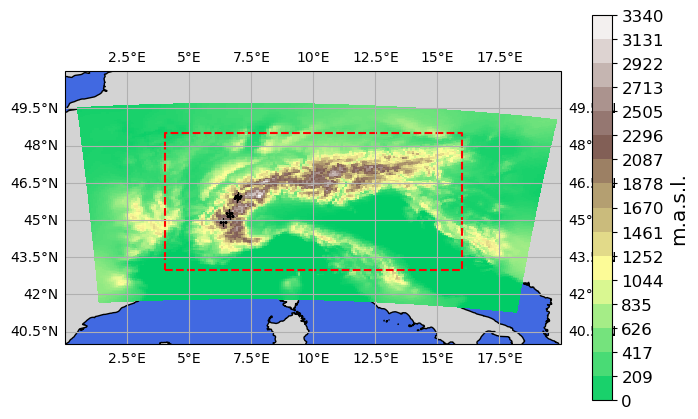

In [17]:
# traduction par ChatGPT d'un script de Ian utilisant proplot pour utiliser matplotlib
#(https://github.com/Ian-CD/PhD/blob/master/Seasonal_Climate.ipynb)

# équivalent du rc figure.facecolor
plt.rcParams['figure.facecolor'] = 'white'

# Colormap
colors_land = plt.cm.terrain(np.linspace(0.25, 1, 256))
cmap_land = plt.matplotlib.colors.ListedColormap(colors_land)

# --- Niveaux réguliers ---
vmin = np.nanmin(dsTopo.SH)
vmax = np.nanmax(dsTopo.SH)
levels = np.linspace(vmin, vmax, 17)  # 17 niveaux
norm = BoundaryNorm(levels, ncolors=cmap_land.N, clip=True)

# Création figure+axes avec projection PlateCarree (cyl)
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# pcolormesh
m = ax.pcolormesh(
    dsTopo.LON, dsTopo.LAT, dsTopo.SH,
    cmap=cmap_land,
    shading='auto' 
)

# Colorbar
#cbar = plt.colorbar(m, ax=ax)
cbar = plt.colorbar(m, ax=ax, boundaries=levels, ticks=levels) # 17 niveaux reguliers
cbar.set_label('m.a.s.l.', fontsize='x-large')
cbar.ax.tick_params(labelsize='large')

## Points
#ax.plot(ds.LON[60,100], ds.LAT[60,100], 'ro', markersize=2, transform=ccrs.PlateCarree())
#ax.plot(7.2, 44.6, 'rx', markersize=3, transform=ccrs.PlateCarree())
#ax.plot(ds.LON[70,45], ds.LAT[70,45], 'rx', markersize=5, transform=ccrs.PlateCarree())

# Limites carte
ax.set_extent([0., 20., 40., 51.], crs=ccrs.PlateCarree())
# Zoom North French Alps
#ax.set_extent([6.2, 7.1, 44.7, 46.1], crs=ccrs.PlateCarree())
# Zoom Mont Blanc
#ax.set_extent([6.8, 7.0, 45.7, 46.0], crs=ccrs.PlateCarree())

# Ajout océans (équivalent ocean=True + oceancolor)
ax.add_feature(cfeature.OCEAN, facecolor='royalblue')
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')

# Tracé du polygone en pointillés rouge
ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())

# Position des glaciers
for i in range(len(glacioClim)):
    print (i,glacioClim[i][:])
    ax.plot(glacioClim[i][1],glacioClim[i][2], marker='+',color='black')


# Format normal: titres, grilles, ticks, etc.
# (il faut expliciter car ProPlot fait beaucoup automatiquement)
ax.gridlines(draw_labels=True)



plt.show()

#Notes de traduction

#    proj='cyl' → ccrs.PlateCarree().

#    ax.format() n’existe pas : on remplace par set_extent, gridlines, add_feature, etc.

#    ocean=True → ax.add_feature(cfeature.OCEAN).

#    pcolormesh(..., levels=17) n’est pas un paramètre dans matplotlib pour pcolormesh.
#    niveaux réguliers via norm=BoundaryNorm.

In [18]:
AltZoom = dsTopo.SH

2. Tests to Plot temperature from 1 data file (eq. 1 year)

In [19]:
# Information on the first file
year=1985#first_year
file1=path_MARSIMU+'/'+scenario+'/'+data_freq+'/'+data_freq_prefix+'.'+name_GCM+'_'+scenario+'.'+sim+'.TTz.'+str(year)+'.nc'
print(file1)
ds = xr.open_dataset(file1) # Alternative #ds = xr.open_dataset(os.path.join(path,file))

/bettik/beaumetj/MARout//MAR-EC-Earth3//HIST/monthly/MON.EC-Earth3_HIST.EUe.TTz.1985.nc


In [20]:
#ds # xarray.Dataset (Dimensions: x: 201y: 126ztqlev: 4time: 12bnds: 2)

2.1 Plot map of temperature (1 year)

0 ['Argentiere', 6.93, 45.9]
1 ['Mer de Glace', 6.97, 45.95]
2 ['Gebroulaz', 6.61, 45.28]
3 ['Saint Sorlin', 6.63, 45.15]
4 ['Glacier Blanc', 6.37, 44.93]


Text(0.5, 1.0, 'Mean Temperature (MON.EC-Earth3_HIST.EUe.TTz.1985.nc)')

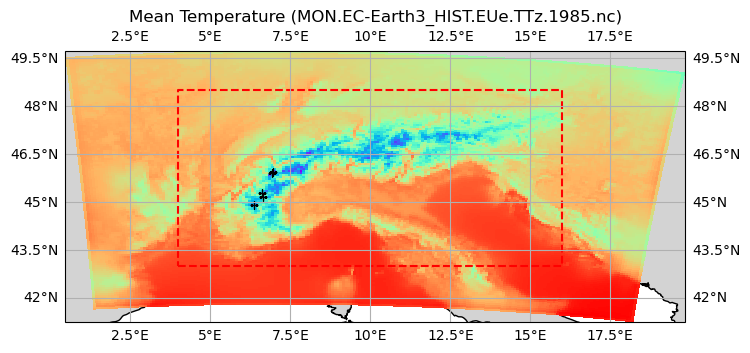

In [21]:
# Creation figure+axes with projection PlateCarree (cyl)
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# pcolormesh
m = ax.pcolormesh(
    dsTopo.LON, dsTopo.LAT, ds.TTz.mean("time")[0],
    cmap='rainbow', shading='auto' 
)
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black') # facecolor='none'
# Tracé du polygone en pointillés rouge
ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())

# Position des glaciers
for i in range(len(glacioClim)):
    print (i,glacioClim[i][:])
    ax.plot(glacioClim[i][1],glacioClim[i][2], marker='+',color='black')

ax.gridlines(draw_labels=True)
    
JustFilename = file1.rsplit('/', 1)[-1] # split at / ; filename is the last occurence
ax.set_title(f'Mean Temperature ({JustFilename})')

2.2 extract temperature at Glacier location (1 year)

In [22]:
#ds.TTz.mean("time")[0].sel(x=xloc,y=yloc,method='nearest')
##ds.time

#Ttime= ds.TTz.sel(x=xloc,y=yloc,ztqlev=2,method='nearest')
#plt.plot(ds.time,Ttime)

Text(0.5, 0.98, 'Temperature at 4 locations (MON.EC-Earth3_HIST.EUe.TTz.1985.nc)')

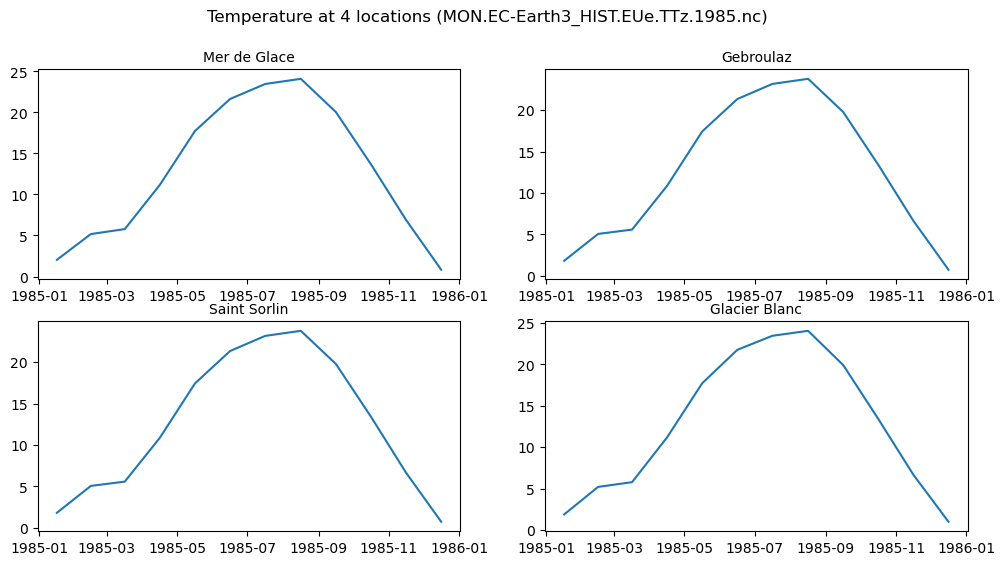

In [23]:
#Plot temperature pour 4 glacier
fig, axs = plt.subplots(2, 2, figsize=(12, 6))
axs = axs.ravel()

for i, ax in enumerate(axs):
    glaName,xloc,yloc = glacioClXY[i+1][:] # i+1 because 5 glaciers and 2 first are in same pixel (Arg and MdG)
    #print(glaName,xloc,yloc)
    Ttime= ds.TTz.sel(x=xloc,y=yloc,ztqlev=2,method='nearest')
    ax.plot(ds.time,Ttime)
    ax.set_title(glaName,fontsize=10)
fig.suptitle(f"Temperature at 4 locations ({JustFilename})", fontsize=12)

2.3 seasonal temperature (1 year)

In [24]:
seasonal_mean = ds.TTz.groupby("time.season").mean(dim="time")[:,0].sortby(xr.DataArray(['DJF','MAM','JJA', 'SON'],dims=['season']))

In [25]:
seasonal_mean.shape
#seasonal_mean

(4, 126, 201)

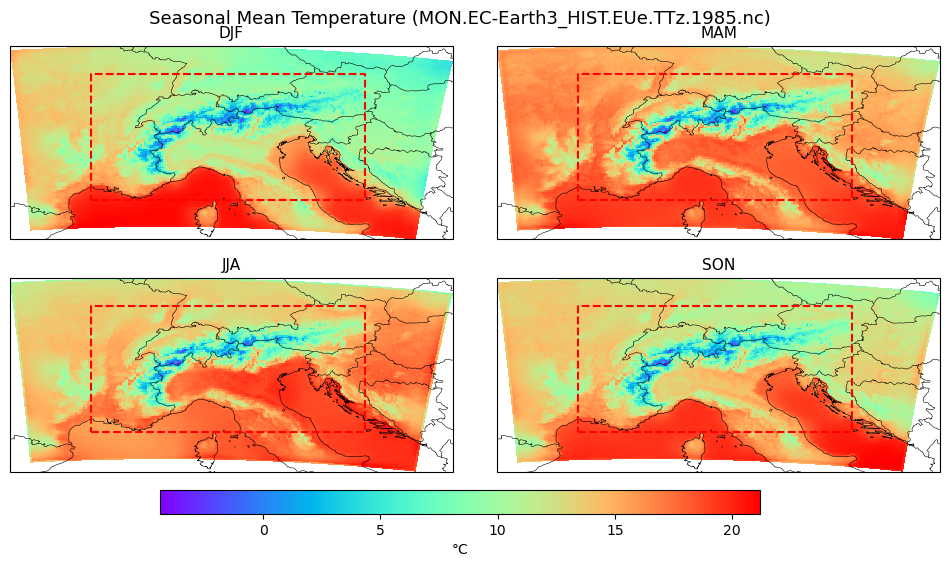

In [26]:
proj = ccrs.PlateCarree()

# Fixed color levels
levels = np.arange(-32, 32+2, 2)
cmap, quality = plt.get_cmap('rainbow'), 100
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

# Latitude and longitude coordinates for gridlines
lat_ticks = np.arange(28, 44, 4)
lon_ticks = np.arange(64, 108, 4)

fig, axs = plt.subplots(2, 2, figsize=(12, 6),
                        subplot_kw={'projection': proj},dpi=quality)
axs = axs.ravel()

for i, ax in enumerate(axs):
    pcm = ax.pcolormesh(dsTopo.LON, dsTopo.LAT, seasonal_mean[i], 
    cmap='rainbow', shading='auto'
)
 #                       cmap=cmap, shading='auto', norm=norm)
    
    # Geographic features
    ax.add_feature(cfeature.COASTLINE, lw=0.4)
    ax.add_feature(cfeature.BORDERS, lw=0.4)
    # Tracé du polygone en pointillés rouge
    ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())
    
#    ax.set_extent([lon1, lon2, lat1, lat2-3])
    
    # Gridlines at specified coordinates with labels
    gl = ax.gridlines(draw_labels=True, lw=0.3, color='gray', alpha=0.5)
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = gl.ylabel_style = {'size': 8}
    
    gl.xlocator = FixedLocator(lon_ticks)
    gl.ylocator = FixedLocator(lat_ticks)
    
    ax.set_title(seasonal_mean.season.data[i], fontsize=11)

# Tight layout
plt.subplots_adjust(wspace=0.1, hspace=0.01)

# Horizontal colorbar
cbar_ax = fig.add_axes([0.25, 0.07, 0.5, 0.04])
fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal', label='°C')

JustFilename = file1.rsplit('/', 1)[-1] # split at / ; filename is the last occurence
fig.suptitle(f"Seasonal Mean Temperature ({JustFilename})", fontsize=13, y=0.91)
plt.show()

3. Open temperature data file for all years

In [27]:
# TTz
T_month = np.zeros(((last_year-first_year+1),12,91,139))
T_season= np.zeros(((last_year-first_year+1), 4,91,139))
# 4 dimensions : year, month, AND lon, lat ???  
T_month.shape

(55, 12, 91, 139)

In [28]:
# Open files and copy data in Arrays T_month and T_season (for months and saisons data)
for year in list(range(first_year,last_year+1)):
    print(year,end=' ')
    #if year == 1985 or year == 2071:
    #    continue
    hist_path = path_MAR+'MAR-'+name_GCM+'/HIST/'+data_freq+'/'+data_freq_prefix+'.'+name_GCM+'_HIST.'+sim+'.TTz.'+str(year)+'.nc'
    ssp245_path = path_MAR+'MAR-'+name_GCM+'/SSP245/'+data_freq+'/'+data_freq_prefix+'.'+name_GCM+'_SSP245.'+sim+'.TTz.'+str(year)+'.nc'
    if year <2015:
        ds_var = xr.open_dataset(hist_path)
    else:
        #ds_T = xr.open_dataset('/bettik/beaumetj/MARout/MAR-EC-Earth3/SSP245/monthly/MON.EC-Earth3_SSP245.EUe.TTz.'+str(year)+'.nc')
        ds_var = xr.open_dataset(ssp245_path)
        print("ssp245_path")
    T_month[year-1961]=ds_var.TTz.isel(ztqlev=0)[:,jmin:jmax,imin:imax]
    T_season[year-1961]=season_mean(ds_var.TTz.sel(ztqlev=2)).sortby(xr.DataArray(['DJF','MAM','JJA', 'SON'],dims=['season']))[:,jmin:jmax,imin:imax]
    seasonal_mean_year=season_mean(ds_var.TTz.sel(ztqlev=2)).sortby(xr.DataArray(['DJF','MAM','JJA', 'SON'],dims=['season']))
    #if ds_var.TTz.isel(ztqlev=0)[jmin,imin]==0.:
    #print(year,hist_path,T_month[year-1961,1,10,10])

1961 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 ssp245_path


In [29]:
#T_month # array shape=(5, 12, 91, 139))
#seasonal_mean_year # xarray.DataArray (season: 4 y: 126 x: 201) # Il is for 1 year = Useless ???
#T_season # array shape=(5, 4, 91, 139)
#dsTopo.LON # xarray.DataArray shape=(126,201)

In [30]:
T_month[24]

array([[[10.94740582, 10.98740673, 11.0177927 , ...,  9.95415115,
          9.92472076,  9.8947916 ],
        [10.85289669, 10.8901062 , 10.91347313, ...,  9.91800785,
          9.89031601,  9.8502779 ],
        [10.75171566, 10.79458046, 10.83427525, ...,  9.88708973,
          9.8485508 ,  9.80383015],
        ...,
        [ 4.64498281,  4.55138206,  4.50407982, ..., -0.61859453,
         -0.76795489, -0.81036204],
        [ 4.47955847,  3.98129296,  3.76712251, ..., -0.79266286,
         -0.92504501, -0.87741864],
        [ 4.31848478,  3.93267274,  3.77113938, ..., -0.66531181,
         -0.81306839, -0.83814573]],

       [[11.68182755, 11.73555851, 11.78741074, ..., 10.86458969,
         10.88281155, 10.90607929],
        [11.610569  , 11.66149044, 11.70543766, ..., 10.81947994,
         10.83574772, 10.85408211],
        [11.54570103, 11.59991169, 11.64719486, ..., 10.77390575,
         10.78226757, 10.79673958],
        ...,
        [ 5.95519829,  5.90582991,  5.75990534, ...,  

3.1 Deux figures de temperature annuelles avec 2 methodes

Text(0.5, 1.0, 'Mean Temperature (MON.EC-Earth3_HIST.EUe.TTz.1985.nc)')

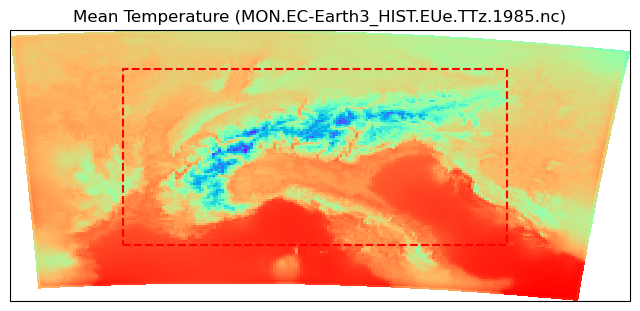

In [31]:
# First : Figure avec 1 fichier xarray aray ds.TTz !!! Rien de neuf c'est deja fait au dessus

# Création figure+axes avec projection PlateCarree (cyl)
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# pcolormesh
m = ax.pcolormesh(
    dsTopo.LON, dsTopo.LAT, ds.TTz.mean("time")[0],
    cmap='rainbow',
    shading='auto' 
)

# Tracé du polygone en pointillés rouge
ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())

JustFilename = file1.rsplit('/', 1)[-1] # split at / ; filename is the last occurence
ax.set_title(f'Mean Temperature ({JustFilename})')

Text(0.5, 1.0, 'Mean Temperature (1961)')

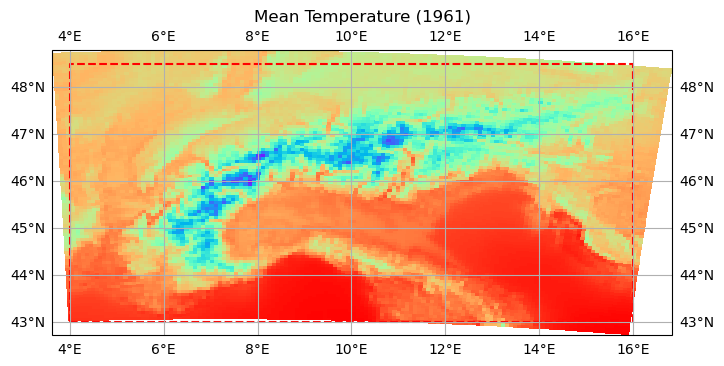

In [32]:
# Second : Figure avec xarray T_month (Zoom Alpes)et tableau de coordonnees du Zoom (Long, Lati)
# Création figure+axes avec projection PlateCarree (cyl)
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

T_year = T_month[0].mean(axis=0) # T_year # array shape=(91, 139)

# pcolormesh
m = ax.pcolormesh(
    Long, Lati, T_year,
    cmap='rainbow',
    shading='auto' 
)

# Tracé du polygone en pointillés rouge
ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())

ax.gridlines(draw_labels=True)


ax.set_title(f'Mean Temperature (1961)')

In [33]:
# Have we the same figure using 1 file and the corresponding data in array T_month ? Yes

3.2 Ploting seasonal means with this second method (ie Array with all years)

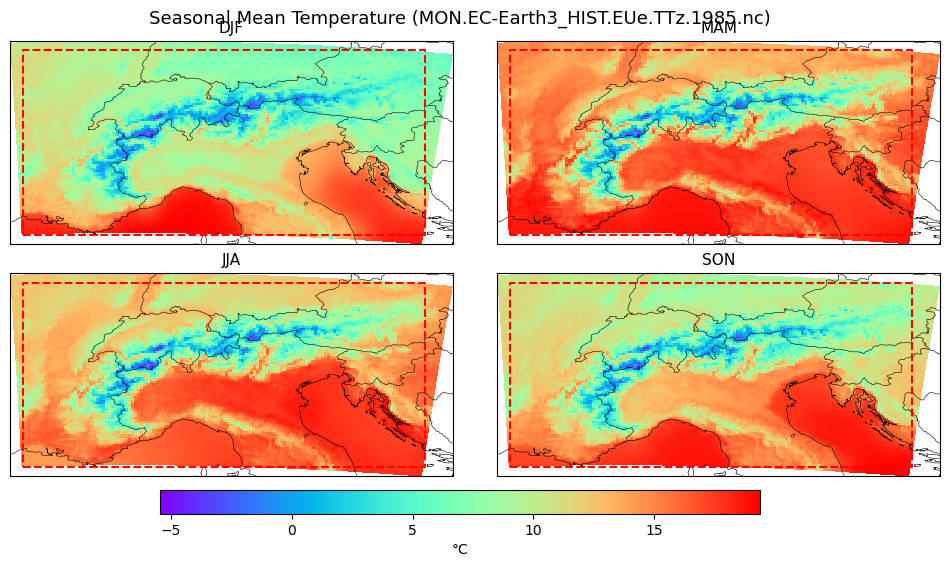

In [34]:
proj = ccrs.PlateCarree()

# Fixed color levels
levels = np.arange(-32, 32+2, 2)
cmap, quality = plt.get_cmap('rainbow'), 100
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

# Latitude and longitude coordinates for gridlines
lat_ticks = np.arange(28, 44, 4)
lon_ticks = np.arange(64, 108, 4)

fig, axs = plt.subplots(2, 2, figsize=(12, 6),
                        subplot_kw={'projection': proj},dpi=quality)
axs = axs.ravel()

for i, ax in enumerate(axs):
    pcm = ax.pcolormesh(Long, Lati, T_season[0,i], 
    cmap='rainbow', shading='auto'
)
 #                       cmap=cmap, shading='auto', norm=norm)
    
    # Geographic features
    ax.add_feature(cfeature.COASTLINE, lw=0.4)
    ax.add_feature(cfeature.BORDERS, lw=0.4)
    # Tracé du polygone en pointillés rouge
    ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())
    
#    ax.set_extent([lon1, lon2, lat1, lat2-3])
    
    # Gridlines at specified coordinates with labels
    gl = ax.gridlines(draw_labels=True, lw=0.3, color='gray', alpha=0.5)
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = gl.ylabel_style = {'size': 8}
    
    gl.xlocator = FixedLocator(lon_ticks)
    gl.ylocator = FixedLocator(lat_ticks)
    
    ax.set_title(seasonal_mean.season.data[i], fontsize=11)

# Tight layout
plt.subplots_adjust(wspace=0.1, hspace=0.01)

# Horizontal colorbar
cbar_ax = fig.add_axes([0.25, 0.07, 0.5, 0.04])
fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal', label='°C')

JustFilename = file1.rsplit('/', 1)[-1] # split at / ; filename is the last occurence
fig.suptitle(f"Seasonal Mean Temperature ({JustFilename})", fontsize=13, y=0.91)
plt.show()

4 Trends

4.1 Regional Trends

In [35]:
slope_T_hist, pvalue_hist = get_slopes_and_pvalue(T_season) # shape=(4, 91, 139)

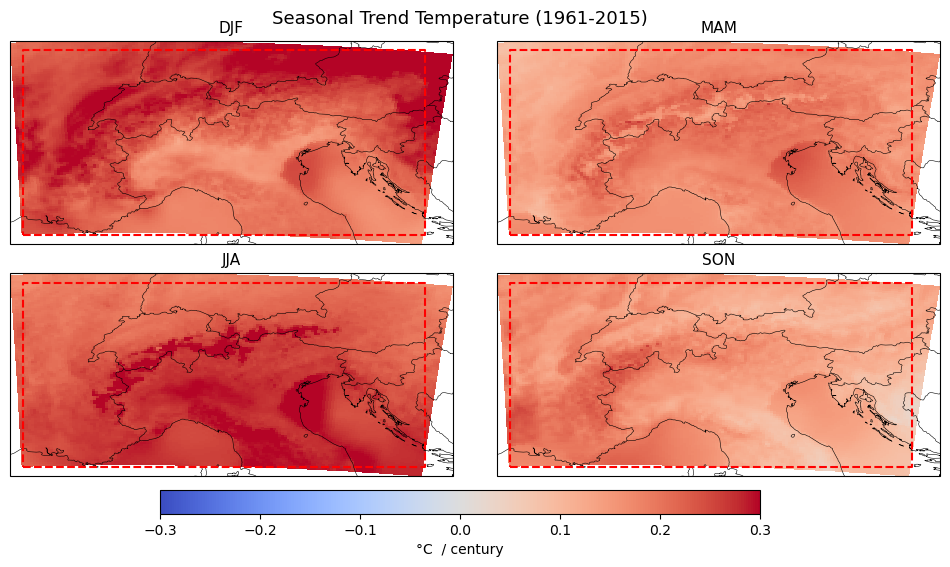

In [36]:
proj = ccrs.PlateCarree()

# Fixed color levels
levels = np.arange(-32, 32+2, 2)
cmap, quality = plt.get_cmap('coolwarm'), 100
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

# Latitude and longitude coordinates for gridlines
lat_ticks = np.arange(28, 44, 4)
lon_ticks = np.arange(64, 108, 4)

fig, axs = plt.subplots(2, 2, figsize=(12, 6),
                        subplot_kw={'projection': proj},dpi=quality)
axs = axs.ravel()

for i, ax in enumerate(axs):
    pcm = ax.pcolormesh(Long, Lati, 10*slope_T_hist[i], 
    cmap='coolwarm', vmin=-.3, vmax=.3
)
 #                       cmap=cmap, shading='auto', norm=norm)
    
    # Geographic features
    ax.add_feature(cfeature.COASTLINE, lw=0.4)
    ax.add_feature(cfeature.BORDERS, lw=0.4)
    # Tracé du polygone en pointillés rouge
    ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())
    
#    ax.set_extent([lon1, lon2, lat1, lat2-3])
    
    # Gridlines at specified coordinates with labels
    gl = ax.gridlines(draw_labels=True, lw=0.3, color='gray', alpha=0.5)
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = gl.ylabel_style = {'size': 8}
    
    gl.xlocator = FixedLocator(lon_ticks)
    gl.ylocator = FixedLocator(lat_ticks)
    
    ax.set_title(seasonal_mean.season.data[i], fontsize=11)

# Tight layout
plt.subplots_adjust(wspace=0.1, hspace=0.01)

# Horizontal colorbar
cbar_ax = fig.add_axes([0.25, 0.07, 0.5, 0.04])
fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal', label='°C  / century')

JustFilename = file1.rsplit('/', 1)[-1] # split at / ; filename is the last occurence
fig.suptitle(f"Seasonal Trend Temperature ({first_year}-{last_year})", fontsize=13, y=0.91)
plt.show()

In [37]:
slope_T_245=slope_T_hist
slope_T_585=slope_T_hist

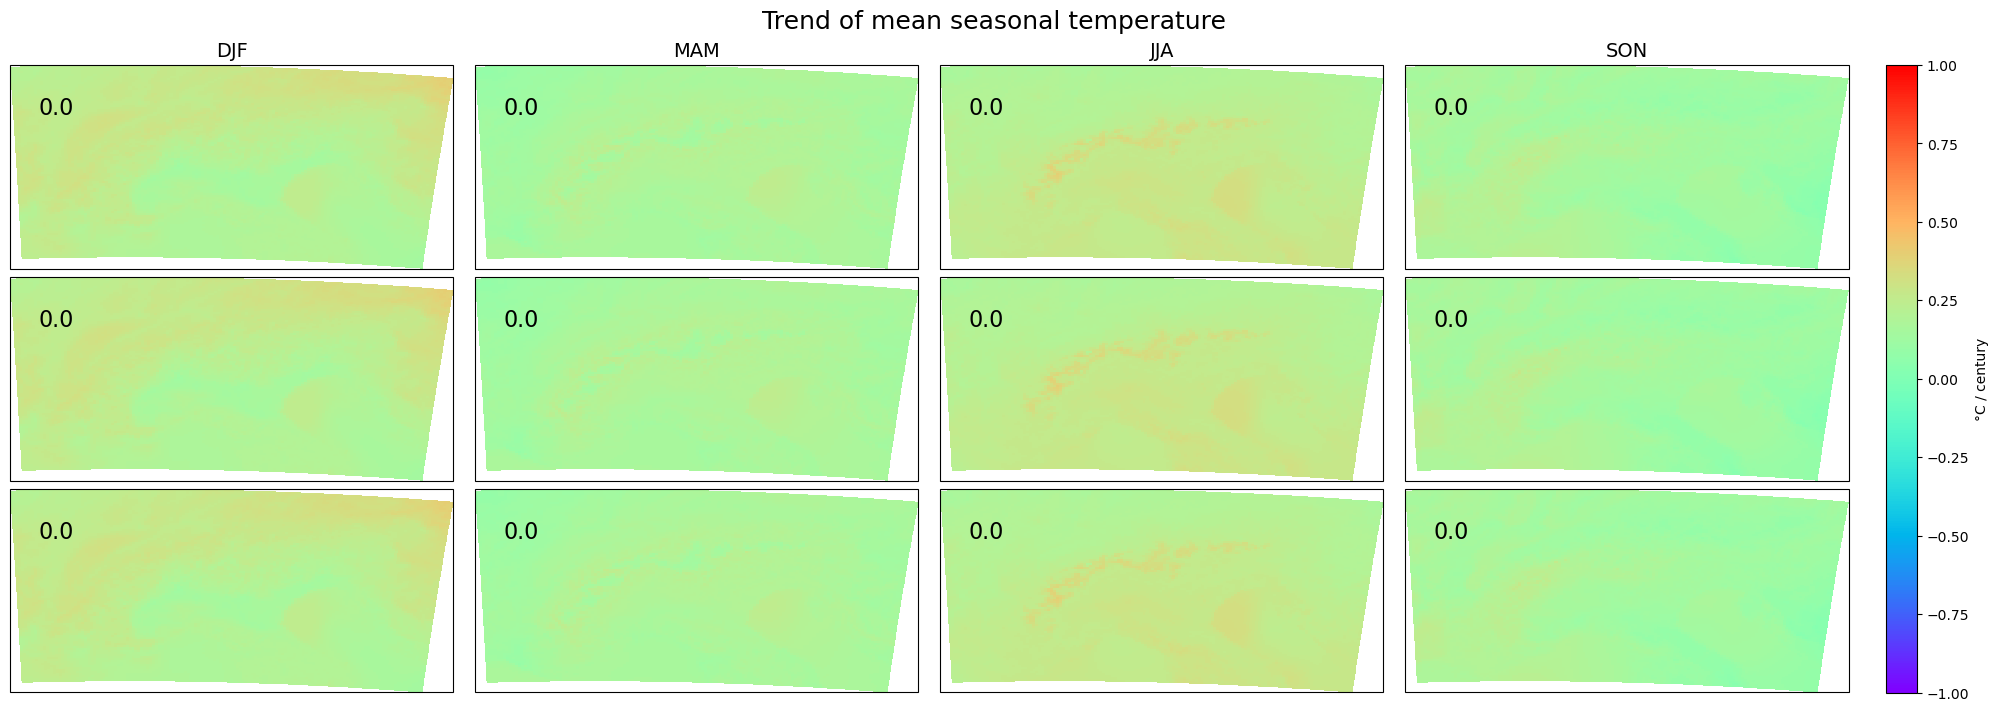

In [38]:
# Plot trends for seasonal temperature for run HISTO, SSPs
fig, axs = plt.subplots(nrows=3, ncols=4,figsize=(20, 7),
    constrained_layout=True,
    subplot_kw={'projection': proj},dpi=quality
)

#levels = np.linspace(0, 8, 65)

# Boucle principale
for i in range(4):
#    pcm = ax.pcolormesh(Long, Lati, slope_T_hist[i], cmap='rainbow', vmin=-1., vmax=1.
#) ### Comment otherwise it shifts the panels

    # ----- HIST -----
    ax = axs[0, i]
    #print("hist",slope_T_hist[i,0,0])
    cb = ax.pcolormesh(Long, Lati, 10*slope_T_hist[i], # 100*slope_T_hist[i] ????????
                       cmap='rainbow', vmin=-1., vmax=1.)
    ax.text(5, 47.5, f"{np.mean(slope_T_hist[i]):.1f}",
            ha='center', va='center', fontsize=16)

    # ----- SSP245 -----
    ax = axs[1, i]
    #print("245",slope_T_245[i,0,0])
    ax.pcolormesh(Long, Lati, 10*slope_T_245[i],
                  cmap='rainbow', vmin=-1., vmax=1.)
    ax.text(5, 47.5, f"{np.mean(slope_T_245[i]):.1f}",
            ha='center', va='center', fontsize=16)

    # ----- SSP585 -----
    ax = axs[2, i]
    #print("585",slope_T_585[i,0,0])
    ax.pcolormesh(Long, Lati, 10*slope_T_585[i],
                  cmap='rainbow', vmin=-1., vmax=1.)
    ax.text(5, 47.5, f"{np.mean(slope_T_585[i]):.1f}",
            ha='center', va='center', fontsize=16)

# ----- Colorbar globale -----
cbar = fig.colorbar(cb, ax=axs, orientation="vertical",
                    fraction=0.025, pad=0.02)
cbar.set_label("°C / century")
#cbar.set_ticks(np.linspace(0, 8, 9))

# ----- Titres colonnes -----
for i, label in enumerate(["DJF", "MAM", "JJA", "SON"]):
    axs[0, i].set_title(label, fontsize=14)
ax.yaxis.set_ticks_position('left')
# ----- Labels lignes -----
for i, label in enumerate(["Hist", "SSP245", "SSP585"]):
    # print(label) !!!! WArning ylabel doesn't appear
    axs[i, 1].yaxis.set_ticks_position('right')
    axs[i, 1].set_ylabel(label, fontsize=114, rotation=90)
axs[1, 1].set_ylabel(label, fontsize=114, rotation=90)

fig.suptitle("Trend of mean seasonal temperature", fontsize=18)

plt.show()

4.1 Trend at glaciers location

In [39]:
# Period over which computing the trends
date1=datetime.date(year=first_year,month=1,day=1)
date2=datetime.date(year=last_year,month=12,day=31)
datesY=pd.date_range(start=date1, end=date2, freq='Y') # years
datesM=pd.date_range(start=date1, end=date2, freq='M') # months
datesM.year

date1m=datetime.date(year=first_year,month=6,day=1)
date2m=datetime.date(year=last_year,month=6,day=30)
datesYm=pd.date_range(start=date1m, end=date2m, freq='Y') # years

datesYm=datesY- datetime.timedelta(days=180) # to put the symbol at the mi-year
datesYm

/tmp/ipykernel_101342/320013518.py:4: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  datesY=pd.date_range(start=date1, end=date2, freq='Y') # years
/tmp/ipykernel_101342/320013518.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datesM=pd.date_range(start=date1, end=date2, freq='M') # months
/tmp/ipykernel_101342/320013518.py:10: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  datesYm=pd.date_range(start=date1m, end=date2m, freq='Y') # years


DatetimeIndex(['1961-07-04', '1962-07-04', '1963-07-04', '1964-07-04',
               '1965-07-04', '1966-07-04', '1967-07-04', '1968-07-04',
               '1969-07-04', '1970-07-04', '1971-07-04', '1972-07-04',
               '1973-07-04', '1974-07-04', '1975-07-04', '1976-07-04',
               '1977-07-04', '1978-07-04', '1979-07-04', '1980-07-04',
               '1981-07-04', '1982-07-04', '1983-07-04', '1984-07-04',
               '1985-07-04', '1986-07-04', '1987-07-04', '1988-07-04',
               '1989-07-04', '1990-07-04', '1991-07-04', '1992-07-04',
               '1993-07-04', '1994-07-04', '1995-07-04', '1996-07-04',
               '1997-07-04', '1998-07-04', '1999-07-04', '2000-07-04',
               '2001-07-04', '2002-07-04', '2003-07-04', '2004-07-04',
               '2005-07-04', '2006-07-04', '2007-07-04', '2008-07-04',
               '2009-07-04', '2010-07-04', '2011-07-04', '2012-07-04',
               '2013-07-04', '2014-07-04', '2015-07-04'],
              dtype

In [40]:
na = last_year-first_year+1
nm = 12* (last_year-first_year+1) # number of months
na,nm

(55, 660)

In [41]:
# Test method for annual temperatures :
T_an_loc = T_month[:,:,10,20]
result = np.average(T_an_loc, axis=1)
#result

In [42]:
# Computing trends (from HMA_climate_trends_CRU notebook)
#slope_T_loc=np.full(seasonal_T_loc.shape[1:4],np.nan) #Return a new array of given shape and type, filled with fill_value
#slope_T_loc=np.full(T_month.shape[1:4],np.nan)
#pvalue_T_loc=np.full(T_month.shape[1:4],np.nan)
#intercept_T_loc=np.full(T_month.shape[1:4],np.nan)
#print(slope_T_loc.shape)

Text(0.5, 1.0, 'Temperature and trend at four Glacioclim locations')

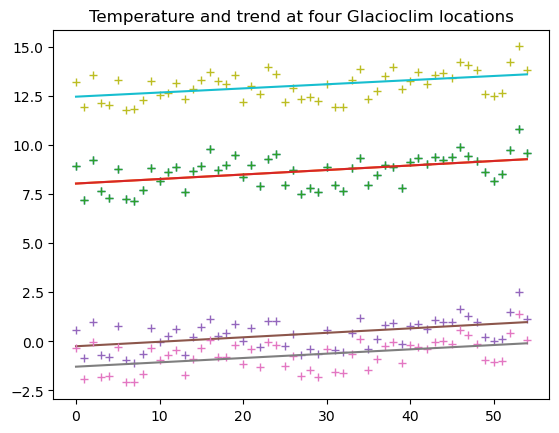

In [43]:
# Computing trends for all Glacioclim glacier
#slope_T_loc=np.full(seasonal_T_loc.shape[1:4],np.nan) #Return a new array of given shape and type, filled with fill_value
slope_T_loc=np.full(5,np.nan)
pvalue_T_loc=np.full(5,np.nan)
intercept_T_loc=np.full(5,np.nan)

#for season in range(4):
#    linregress_T_loc = stats.linregress(range(anual_T_loc.shape[0]-1), seasonal_T_loc[1:,season])
for i in range(len(glacioClXY)):#(last_year-first_year+1):
    glaName,xloc,yloc = glacioClXY[i][:] # i+1 because 5 glaciers and 2 first are in same pixel (Arg and MdG)
    #print(glaName,xloc,yloc)
    T_an_loc = np.average(T_month[:,:,xloc,yloc], axis=1)
    linregress_T_loc = stats.linregress(range(len(T_an_loc)),T_an_loc)
 #   linregress_T_loc = stats.linregress([1961,1962,1963,1964,1965],T_an_loc)
    slope_T_loc[i] = linregress_T_loc.slope
    intercept_T_loc[i] = linregress_T_loc.intercept
    pvalue_T_loc[i] = linregress_T_loc.pvalue
    #print( pvalue_T_loc[i] )
    #plt.plot(datesYm,T_an_loc,marker='o') # T annuelles
    plt.plot(range(len(T_an_loc)), T_an_loc, '+')
    plt.plot(range(len(T_an_loc)), linregress_T_loc.intercept + linregress_T_loc.slope*range(len(T_an_loc)),  label='fitted line')
plt.title(f"Temperature and trend at four Glacioclim locations")

In [44]:
# index
index=np.arange(0,datesY.shape[0])
#index.shape

number of month=660


Text(0.5, 0.98, 'Temperature at 4 locations (1961-2015)')

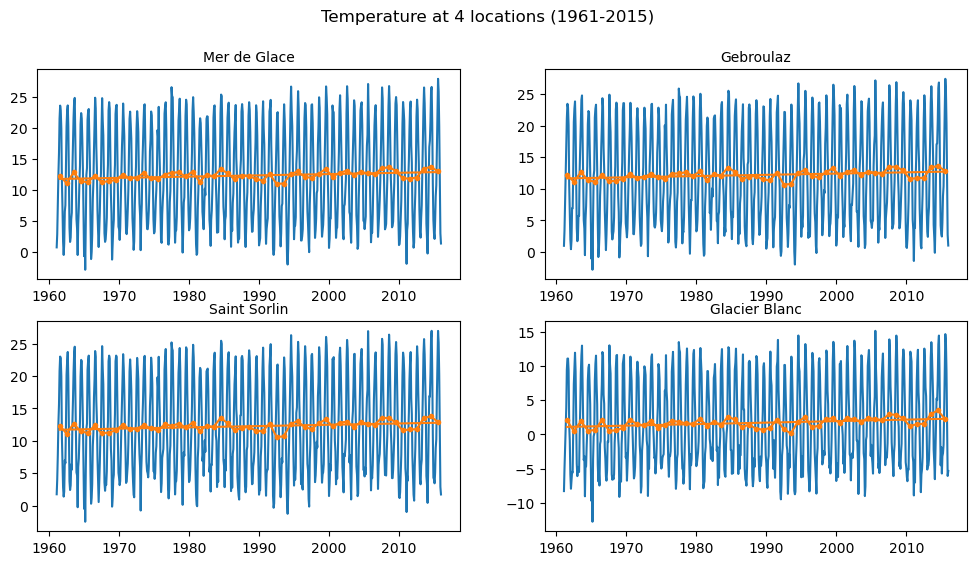

In [45]:
# Calculate trend and plot Temperatures at Glacioclim Location

nm = 12* (last_year-first_year+1) # number of months
print(f"number of month={nm}")

# Computing trends for all Glacioclim glacier (Temperature linear regression)
slope_T_loc=np.full(5,np.nan)
pvalue_T_loc=np.full(5,np.nan)
intercept_T_loc=np.full(5,np.nan)

#Plot temperatures mensuelles pour 4 glacier
fig, axs = plt.subplots(2, 2, figsize=(12, 6))
axs = axs.ravel()

for i, ax in enumerate(axs):
    glaName,xloc,yloc = glacioClXY[i+1][:] # i+1 because 5 glaciers and 2 first are in same pixel (Arg and MdG)
    iloc,jloc = xloc-imin,yloc-jmin # Position dans le tableau zoome
    #print(glaName,xloc,yloc)
    
    T_month_loc = T_month[:,:,iloc,jloc] # axis=0 years, axis=1 months
    T_an_loc = np.average(T_month[:,:,iloc,jloc], axis=1) 
    ax.plot(datesM,T_month_loc.reshape(nm))        # T mensuelles
    ax.plot(datesYm,T_an_loc,marker='.') # T annuelles

    # Computing trends
    linregress_T_loc = stats.linregress(range(len(T_an_loc)),T_an_loc)
    slope_T_loc[i] = linregress_T_loc.slope
    intercept_T_loc[i] = linregress_T_loc.intercept
    pvalue_T_loc[i] = linregress_T_loc.pvalue
    
    signif = 'solid' if pvalue_T_loc[i] < 0.05 else 'dashed'
    #print( T_loc[:] )
    #print( glaName, intercept_T_loc[i+1], slope_T_loc[i+1], np.mean(T_loc[:]) )
    ax.plot(datesYm, linregress_T_loc.intercept + linregress_T_loc.slope*range(len(T_an_loc)),
            linestyle=signif, label='fitted line', color='C1')

    
    ax.set_title(glaName,fontsize=10)
    
fig.suptitle(f"Temperature at 4 locations ({first_year}-{last_year})", fontsize=12)

!!!! Check we have the good coordinates and the good altitude

In [46]:
print ("Annual Trends at Glacioclim location:")
for i in range(len(glacioClXY)):#(last_year-first_year+1):
    glaName,xloc,yloc = glacioClXY[i][:]
    print("%15s : %.4f °C/an"%(glacioClXY[i][0],slope_T_loc[i-1]))

Annual Trends at Glacioclim location:
     Argentiere : nan °C/an
   Mer de Glace : 0.0205 °C/an
      Gebroulaz : 0.0196 °C/an
   Saint Sorlin : 0.0200 °C/an
  Glacier Blanc : 0.0219 °C/an
